In [ ]:
# !pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load and examine the dataset

file_path = '/content/upwork_jobs_final_categorized_synthetic_dates_36months.csv'
df = pd.read_csv(file_path)


# Check unique categories
print("\nUnique categories:")
print(df['category'].unique())
print(f"Number of unique categories: {df['category'].nunique()}")

df.isnull().sum()

# Check date range
# print("\nExamining date format...")
# print(df['published_date'].head())



Unique categories:
['Other/Uncategorized' 'Web Development' 'Sales & Marketing'
 'Software Development' 'Data Science & Analytics' 'Design & Creative'
 'Customer Service' 'HR & Recruiting' 'Accounting & Consulting'
 'Writing & Translation' 'Admin Support' 'Engineering & Architecture'
 'Mobile Development' 'Legal']
Number of unique categories: 14


,0
title,0
link,0
description,0
published_date,0
is_hourly,0
hourly_low,0
hourly_high,0
budget,0
country,0
category,0


In [ ]:
# Convert 'published_date' to datetime

df['published_date'] = pd.to_datetime(df['published_date'])

# Set 'published_date' as index
df.set_index('published_date', inplace=True)

# Aggregate job counts by category and month

monthly_counts = df.groupby('category').resample('ME').size().unstack(level=0, fill_value=0)


print("\nFirst 5 rows of monthly job counts:")
print(monthly_counts.head())


First 5 rows of monthly job counts:
category        Accounting & Consulting  Admin Support  Customer Service  \
published_date                                                             
2022-01-31                           41             96                11   
2022-02-28                           19             74                 6   
2022-03-31                           23             62                11   
2022-04-30                           34             69                 6   
2022-05-31                           29             98                12   

category        Data Science & Analytics  Design & Creative  \
published_date                                                
2022-01-31                            82                232   
2022-02-28                            48                140   
2022-03-31                            64                171   
2022-04-30                            63                184   
2022-05-31                            76            

In [ ]:
# Save the aggregated data
output_file = 'monthly_job_counts_36m.csv'
monthly_counts.to_csv(output_file)

# Display summary statistics for each category
print("\nSummary statistics for each category:")
category_stats = monthly_counts.describe().T
category_stats['total'] = monthly_counts.sum()
category_stats['avg_monthly'] = monthly_counts.mean()
category_stats = category_stats.sort_values('total', ascending=False)
print(category_stats[['total', 'avg_monthly', 'min', 'max']])





Summary statistics for each category:
                            total  avg_monthly    min    max
category                                                    
Other/Uncategorized         17457   484.916667  203.0  645.0
Web Development              8109   225.250000   77.0  318.0
Design & Creative            6502   180.611111   64.0  258.0
Sales & Marketing            4876   135.444444   54.0  185.0
Writing & Translation        4071   113.083333   42.0  179.0
Software Development         3186    88.500000   29.0  144.0
Admin Support                2930    81.388889   28.0  110.0
Data Science & Analytics     2299    63.861111   19.0   95.0
Accounting & Consulting      1151    31.972222   13.0   57.0
Mobile Development           1131    31.416667   13.0   53.0
Engineering & Architecture    386    10.722222    2.0   19.0
Legal                         358     9.944444    4.0   17.0
HR & Recruiting               322     8.944444    3.0   18.0
Customer Service              280     7.777778

In [ ]:
# !pip install statsmodels

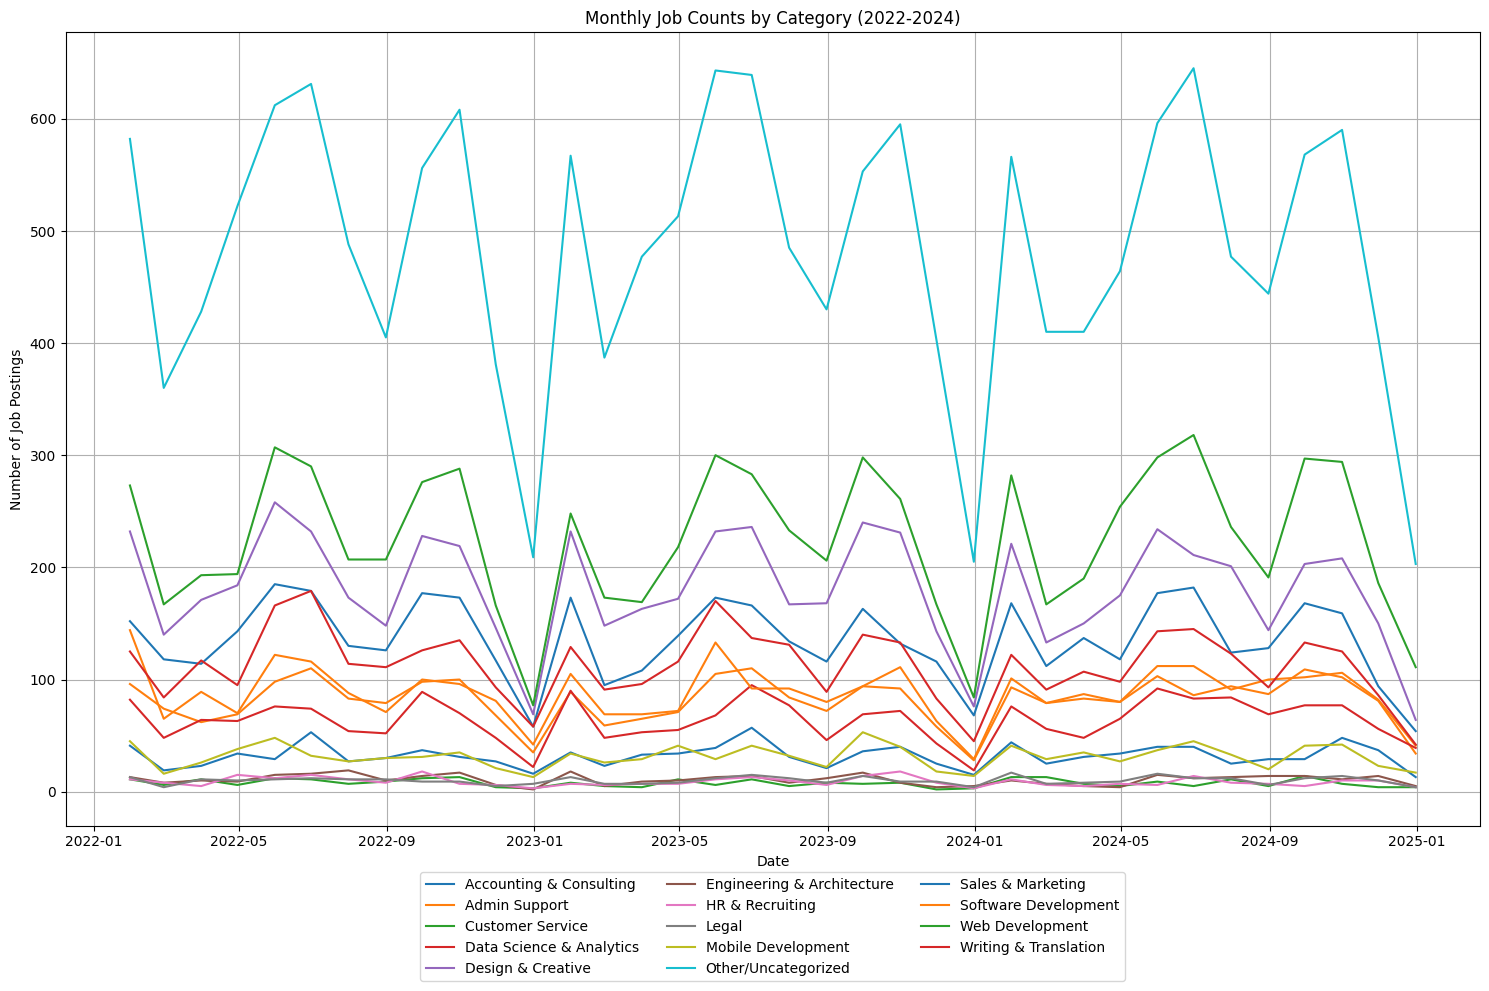

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Load the preprocessed data
monthly_counts = pd.read_csv('monthly_job_counts_36m.csv', index_col='published_date', parse_dates=True)

# Create output directory for plots
import os
if not os.path.exists('time_series_analysis'):
    os.makedirs('time_series_analysis')

#Visualize the overall trend for all categories

plt.figure(figsize=(15, 10))
for category in monthly_counts.columns:
    plt.plot(monthly_counts.index, monthly_counts[category], label=category)
plt.title('Monthly Job Counts by Category (2022-2024)')
plt.xlabel('Date')
plt.ylabel('Number of Job Postings')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.grid(True)
plt.tight_layout()
plt.savefig('time_series_analysis/all_categories_trend.png')
plt.show()
plt.close()

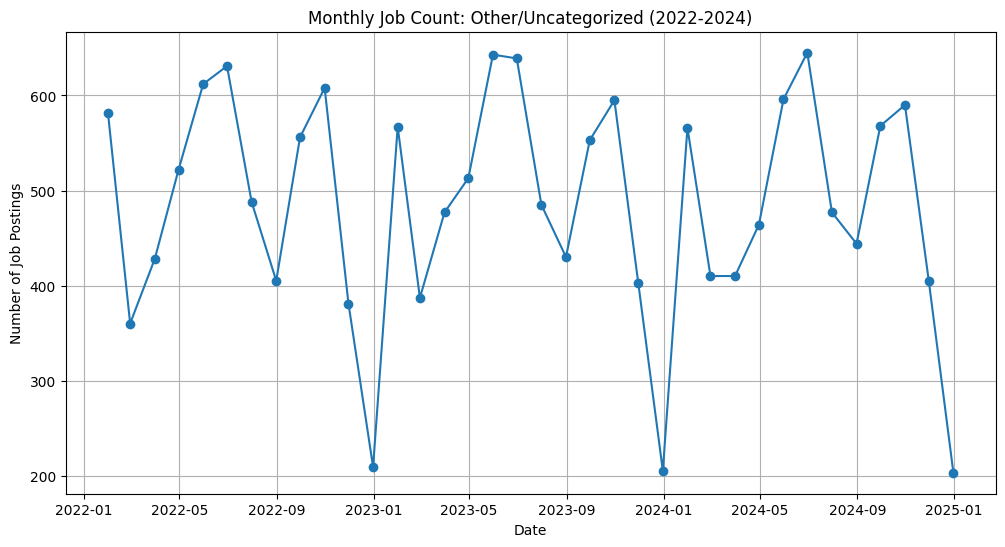

Performing seasonal decomposition for Other/Uncategorized...


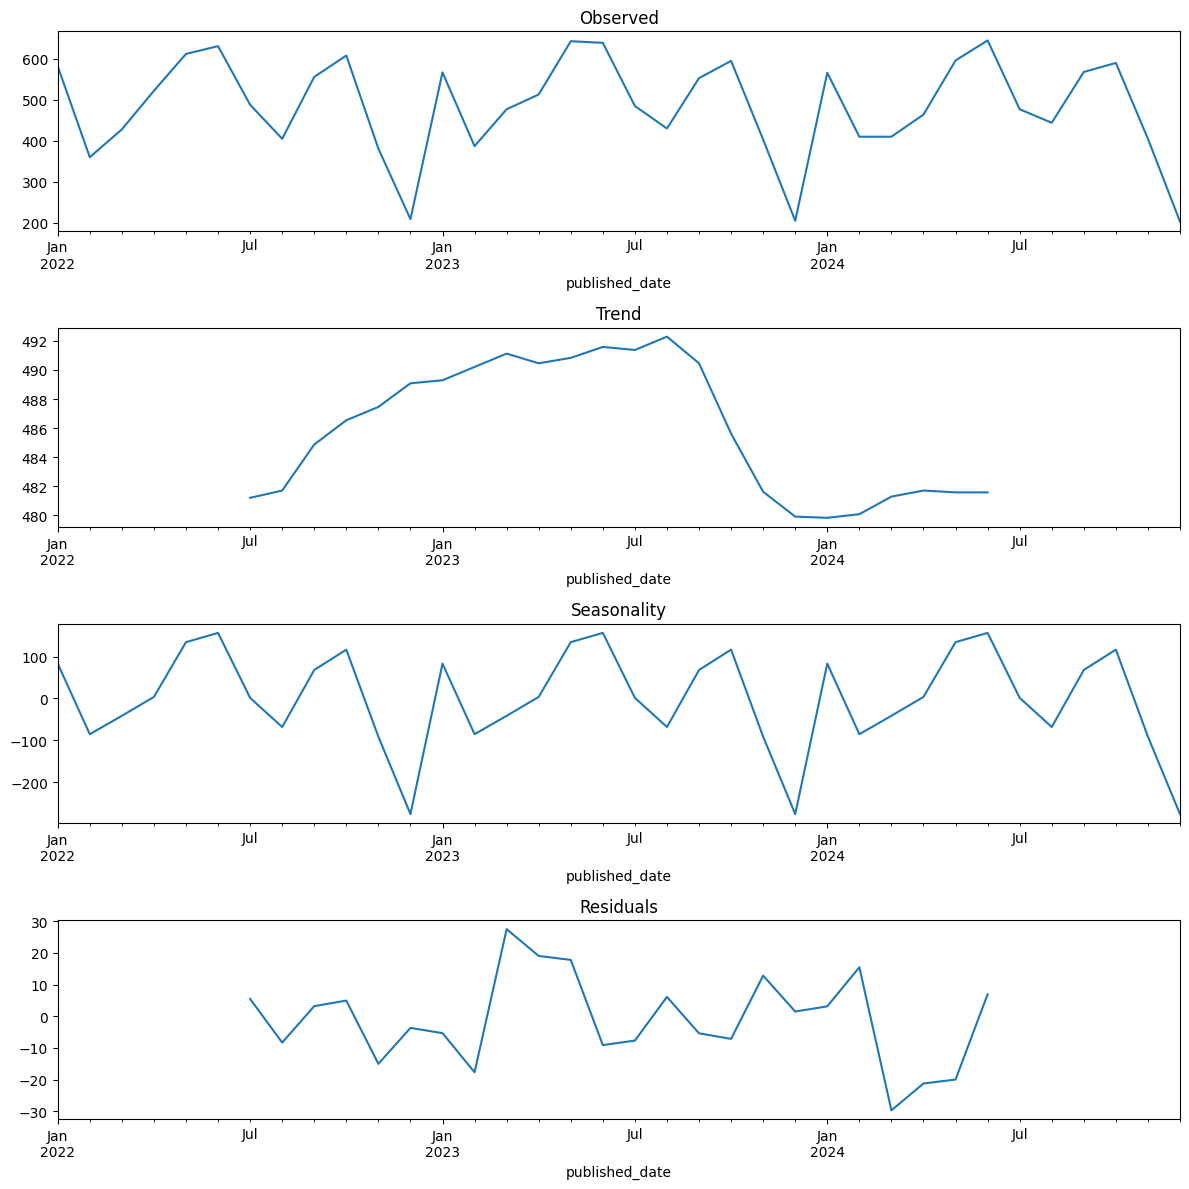

ADF Statistic: -7.0894
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.7238633119999998), '5%': np.float64(-2.98648896), '10%': np.float64(-2.6328004)}
The series is stationary (reject H0)


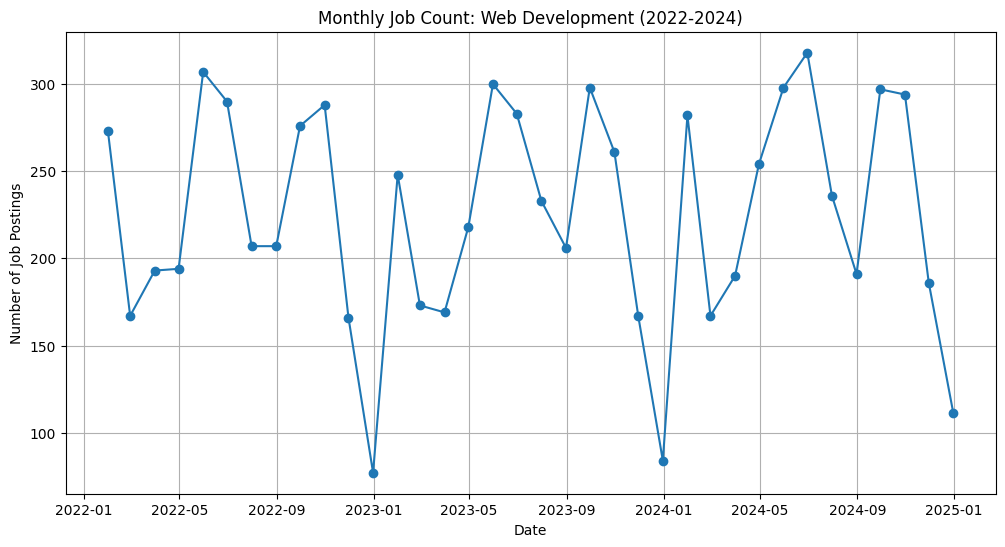

Performing seasonal decomposition for Web Development...


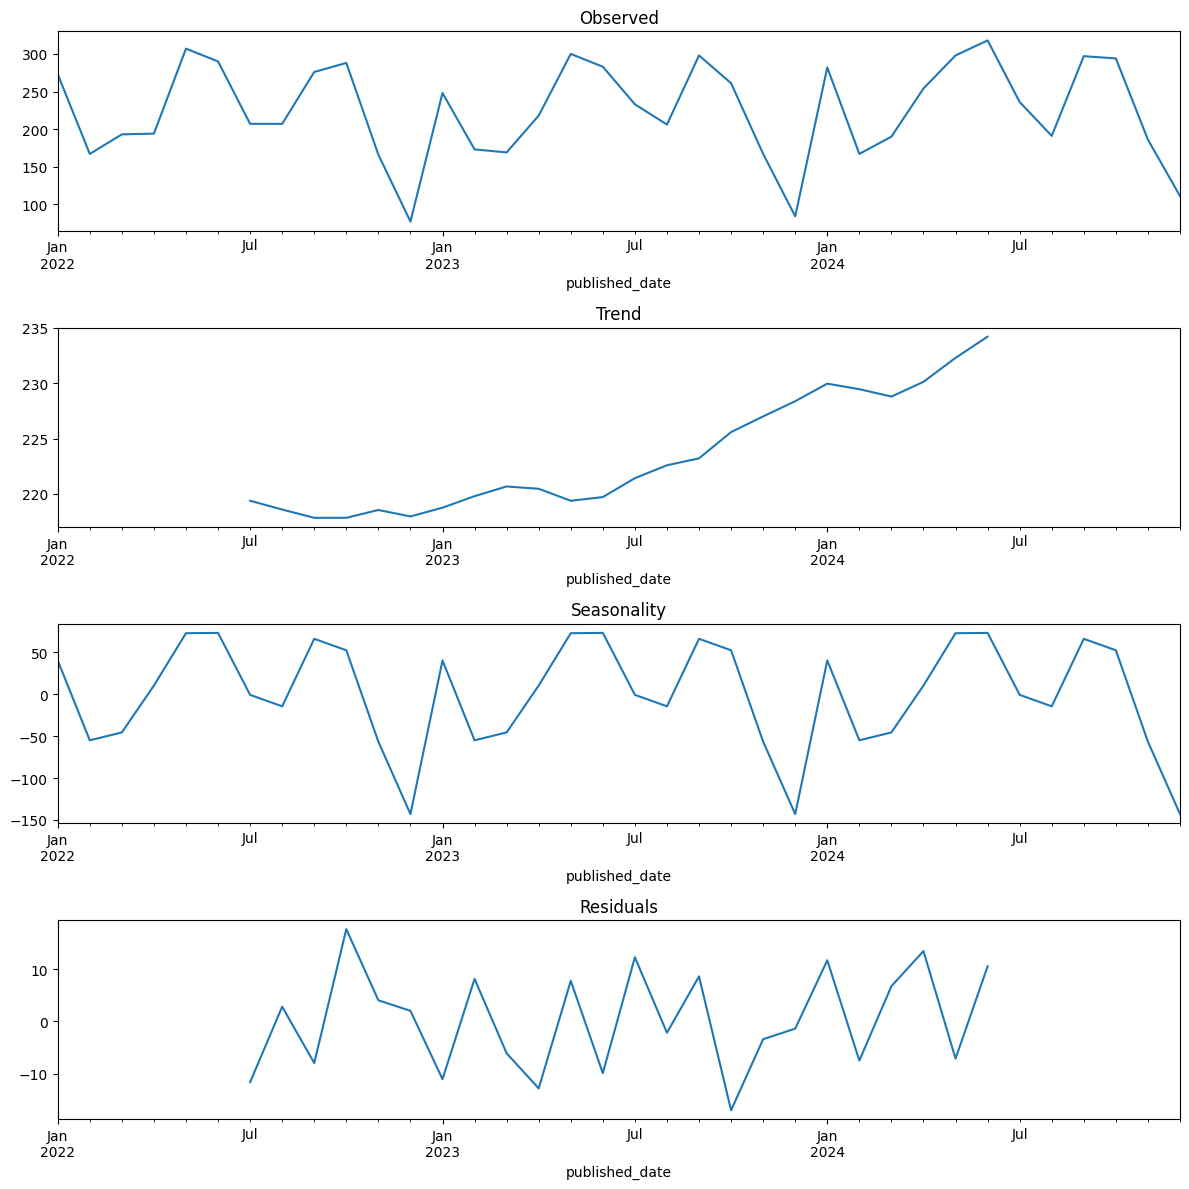

ADF Statistic: -5.0106
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.6790595944893187), '5%': np.float64(-2.9678817237279103), '10%': np.float64(-2.6231583472057074)}
The series is stationary (reject H0)


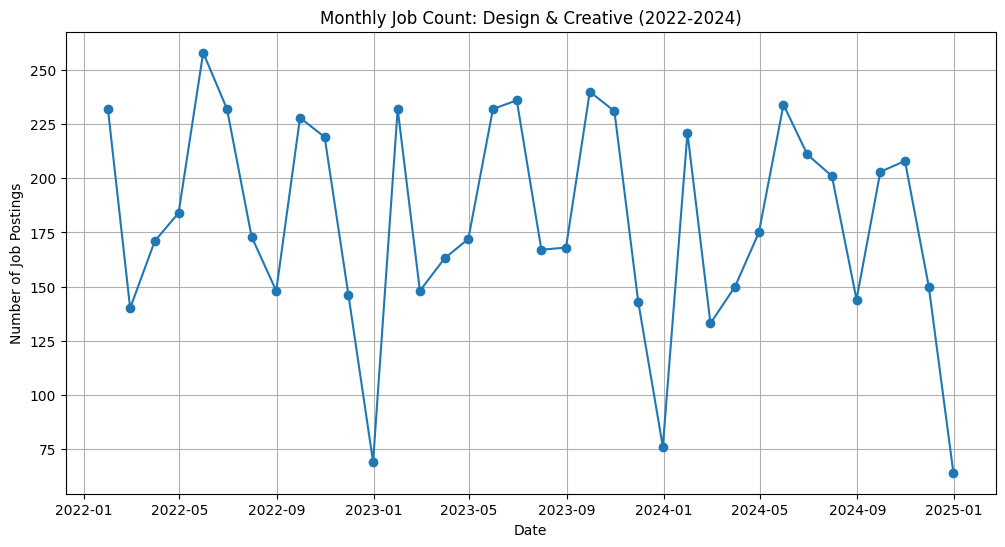

Performing seasonal decomposition for Design & Creative...


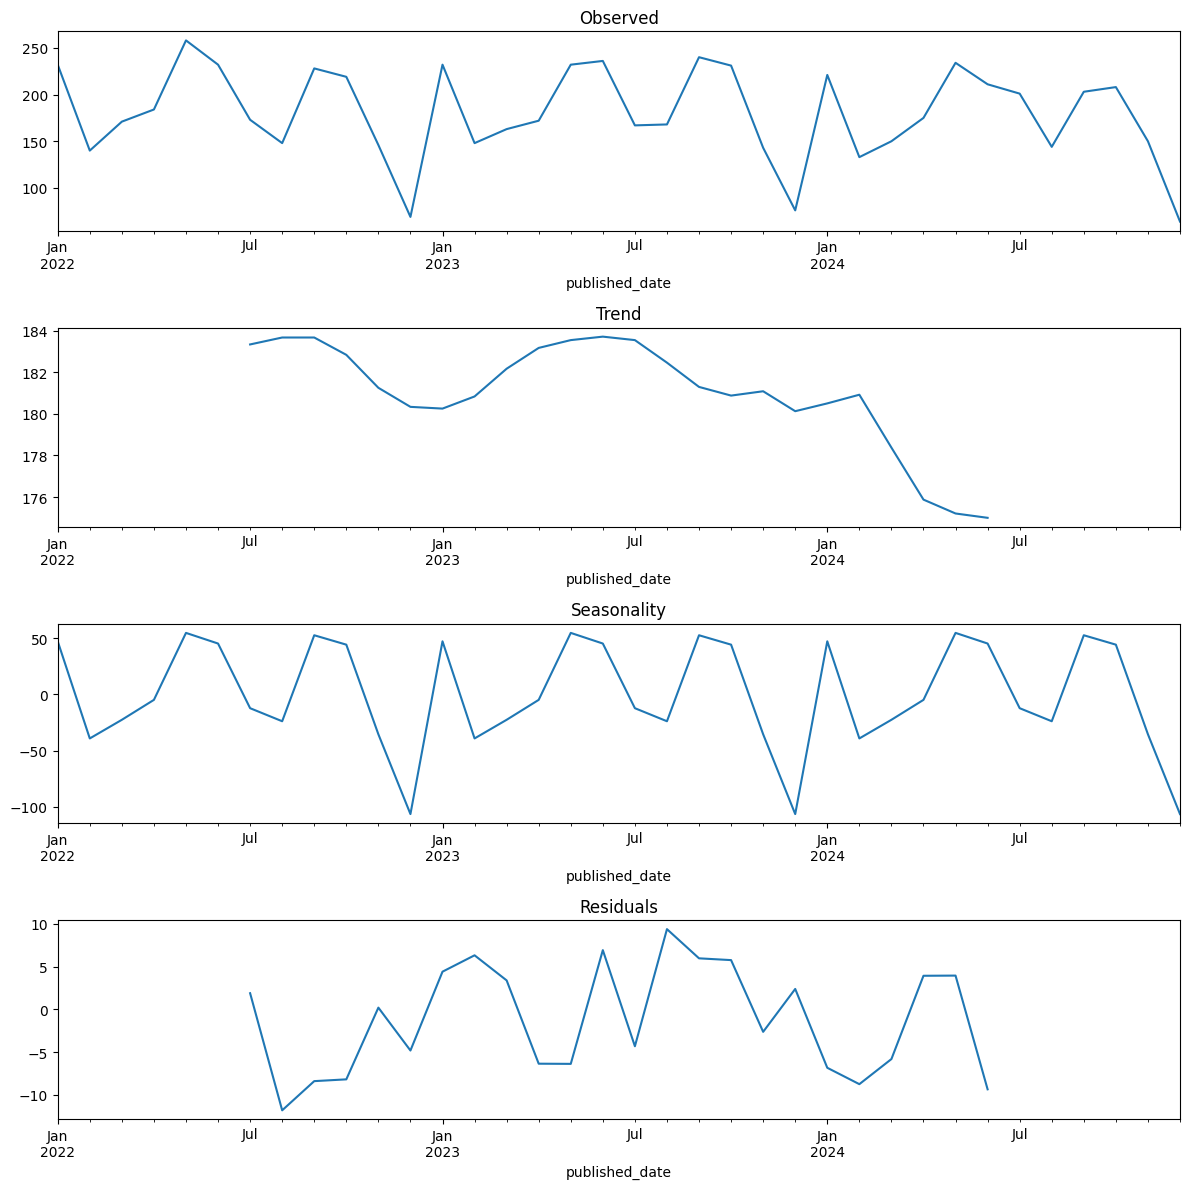

ADF Statistic: -5.0317
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.7238633119999998), '5%': np.float64(-2.98648896), '10%': np.float64(-2.6328004)}
The series is stationary (reject H0)


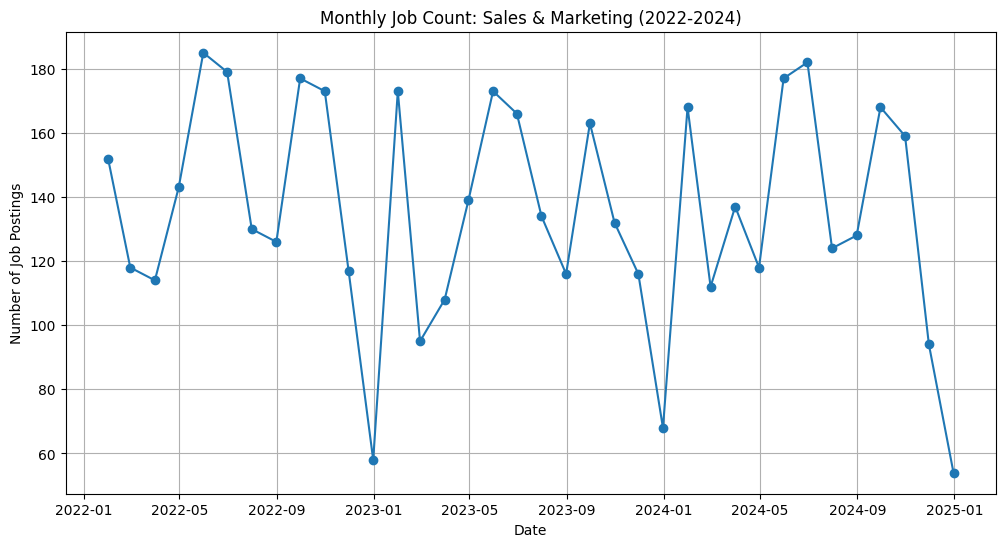

Performing seasonal decomposition for Sales & Marketing...


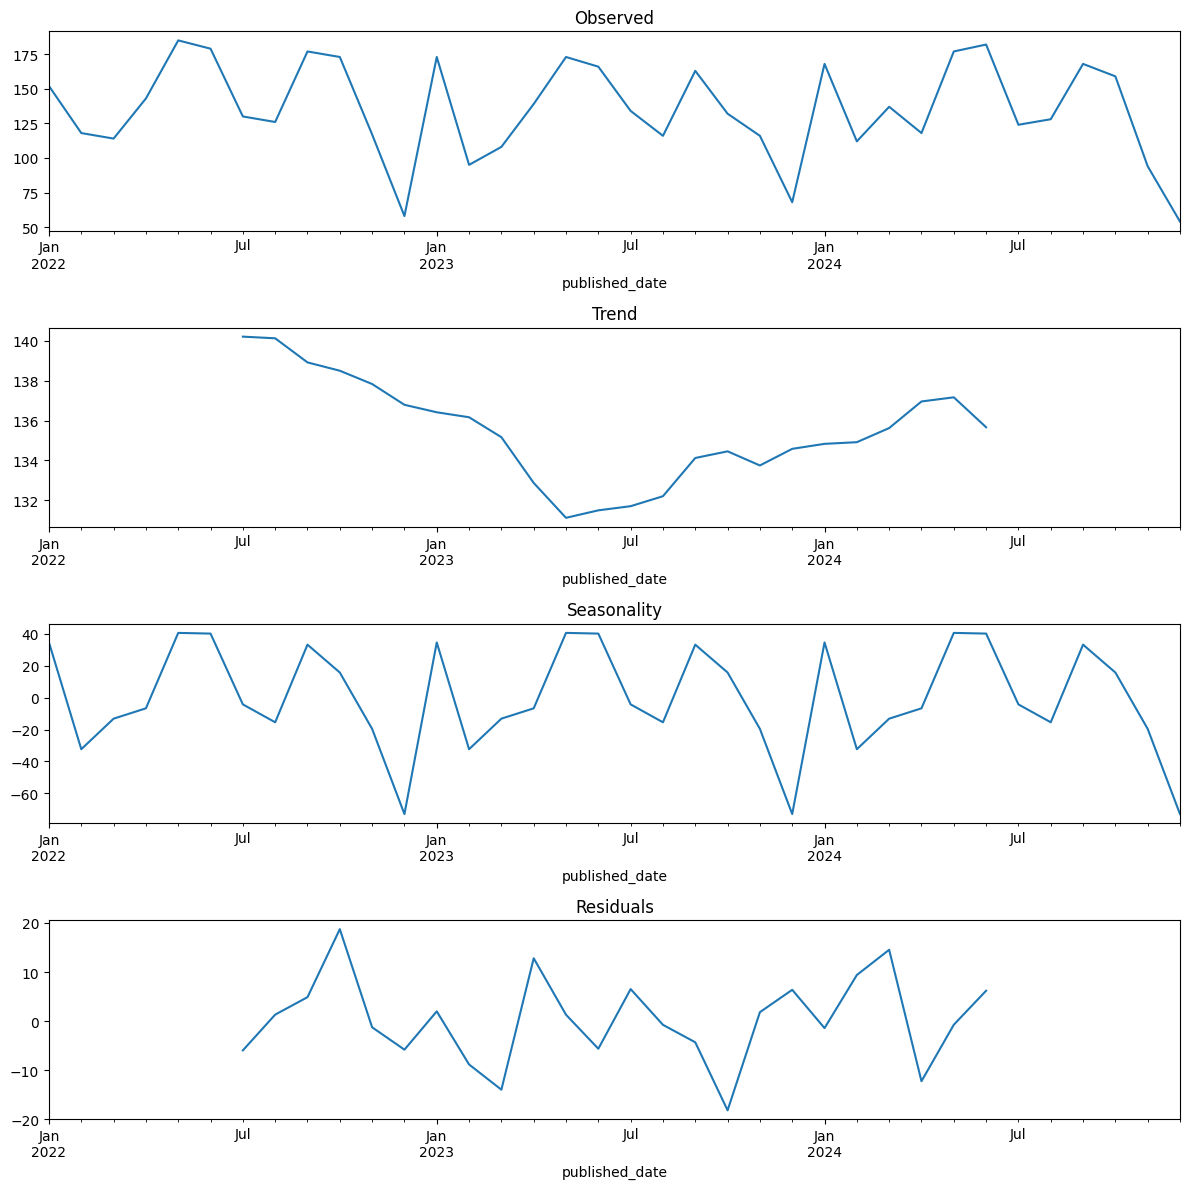

ADF Statistic: -4.6373
p-value: 0.0001
Critical Values: {'1%': np.float64(-3.6790595944893187), '5%': np.float64(-2.9678817237279103), '10%': np.float64(-2.6231583472057074)}
The series is stationary (reject H0)


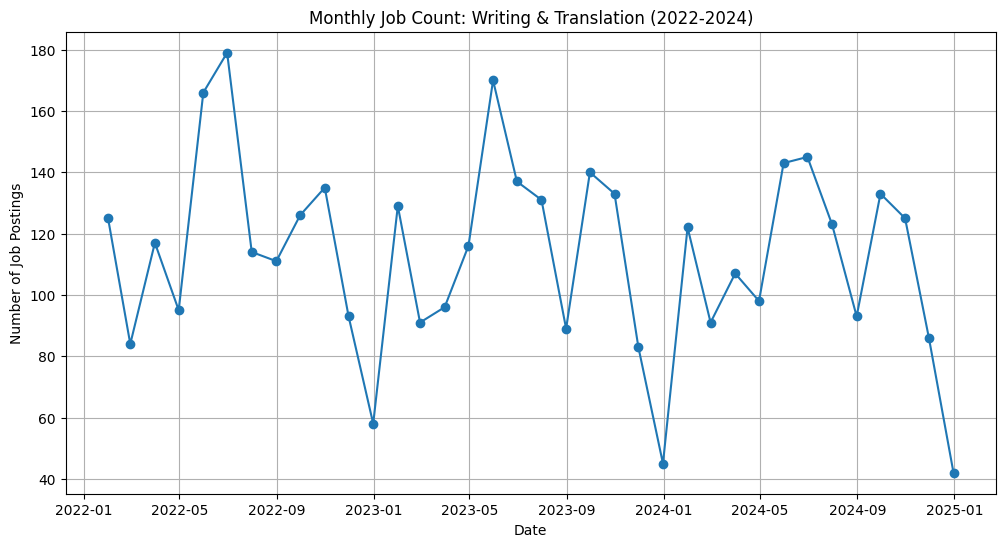

Performing seasonal decomposition for Writing & Translation...


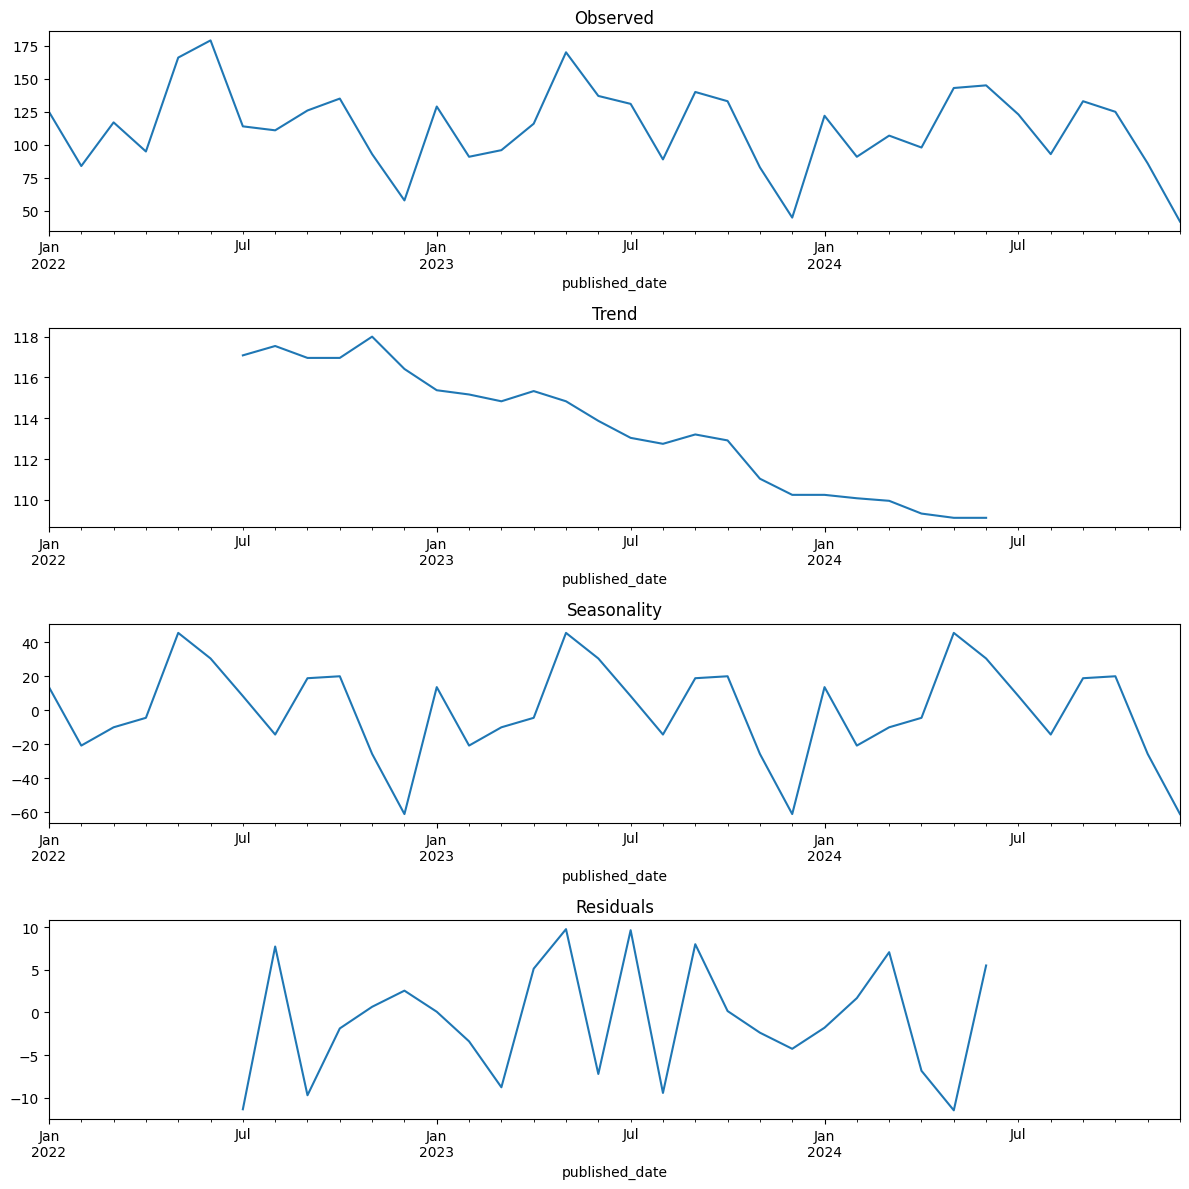

ADF Statistic: -4.9400
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.6790595944893187), '5%': np.float64(-2.9678817237279103), '10%': np.float64(-2.6231583472057074)}
The series is stationary (reject H0)


In [ ]:

# Analyze top 5 categories in detail

top_categories = monthly_counts.sum().sort_values(ascending=False).head(5).index.tolist()

for category in top_categories:

    # Extract the time series for this category
    ts = monthly_counts[category]

    # Plot the time series
    plt.figure(figsize=(12, 6))
    plt.plot(ts.index, ts.values, marker='o')
    plt.title(f'Monthly Job Count: {category} (2022-2024)')
    plt.xlabel('Date')
    plt.ylabel('Number of Job Postings')
    plt.grid(True)
    plt.savefig(f'time_series_analysis/{category.replace("/", "_")}_trend.png')
    plt.show()
    plt.close()

    # Perform seasonal decomposition
    print(f"Performing seasonal decomposition for {category}...")
    decomposition = seasonal_decompose(ts, model='additive', period=12)  # 12 months for yearly seasonality

    # Plot the decomposition
    fig, axes = plt.subplots(4, 1, figsize=(12, 12))
    decomposition.observed.plot(ax=axes[0], title='Observed')
    decomposition.trend.plot(ax=axes[1], title='Trend')
    decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
    decomposition.resid.plot(ax=axes[3], title='Residuals')
    plt.tight_layout()
    plt.savefig(f'time_series_analysis/{category.replace("/", "_")}_decomposition.png')
    plt.show()
    plt.close()

    # Check for stationarity (important for time series modeling)
    result = adfuller(ts.values)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] <= 0.05:
        print("The series is stationary (reject H0)")
    else:
        print("The series is non-stationary (fail to reject H0)")


Creating heatmap to visualize monthly patterns...


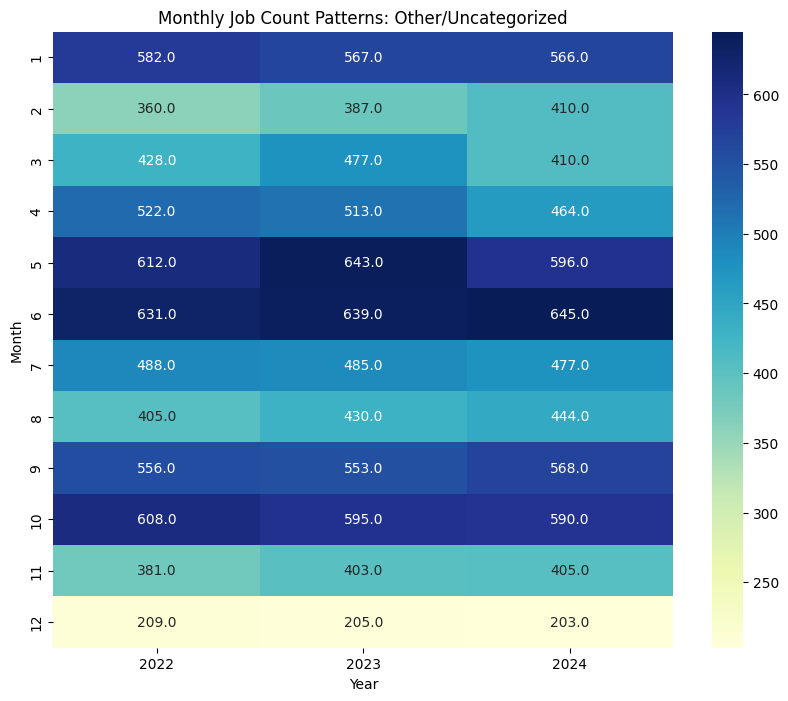

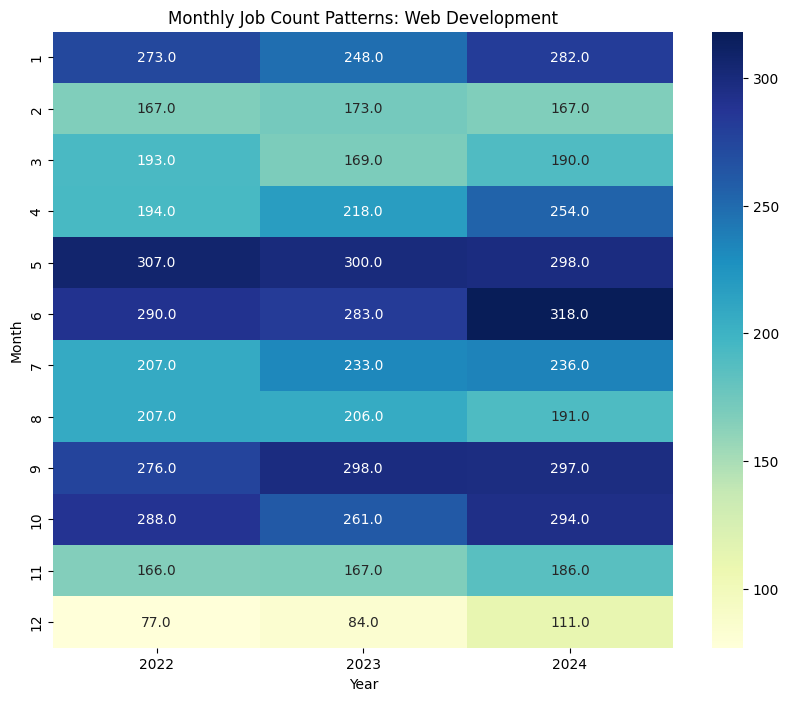

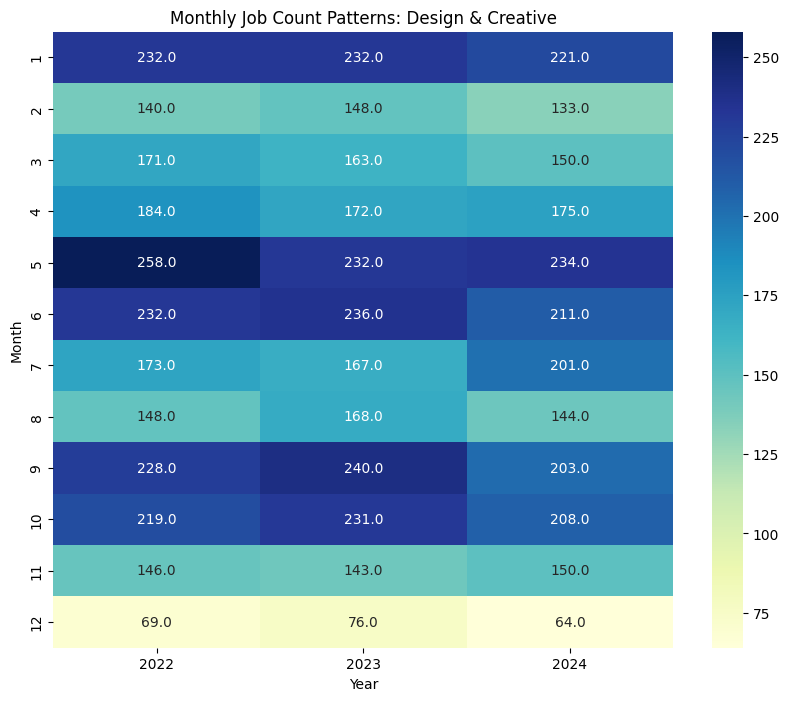

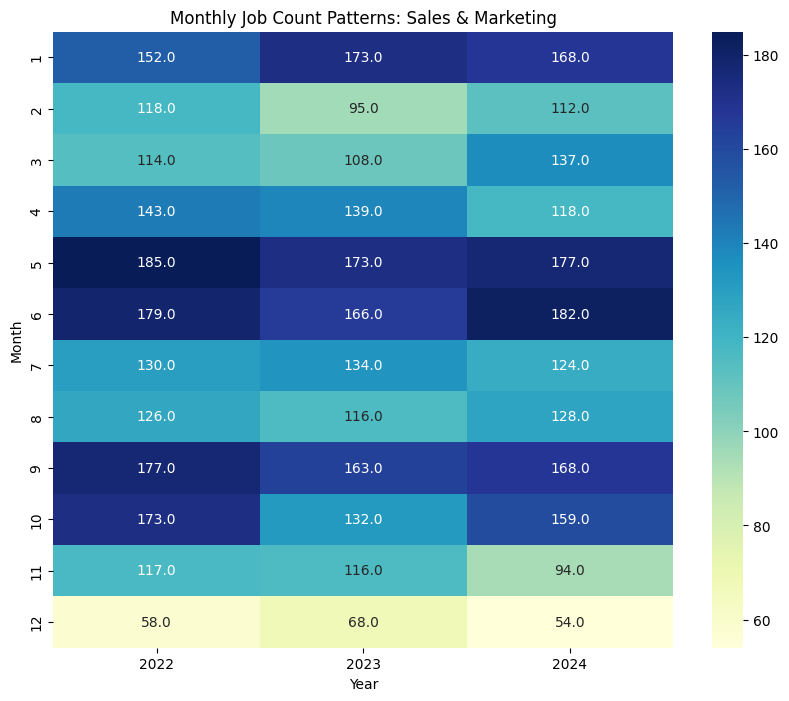

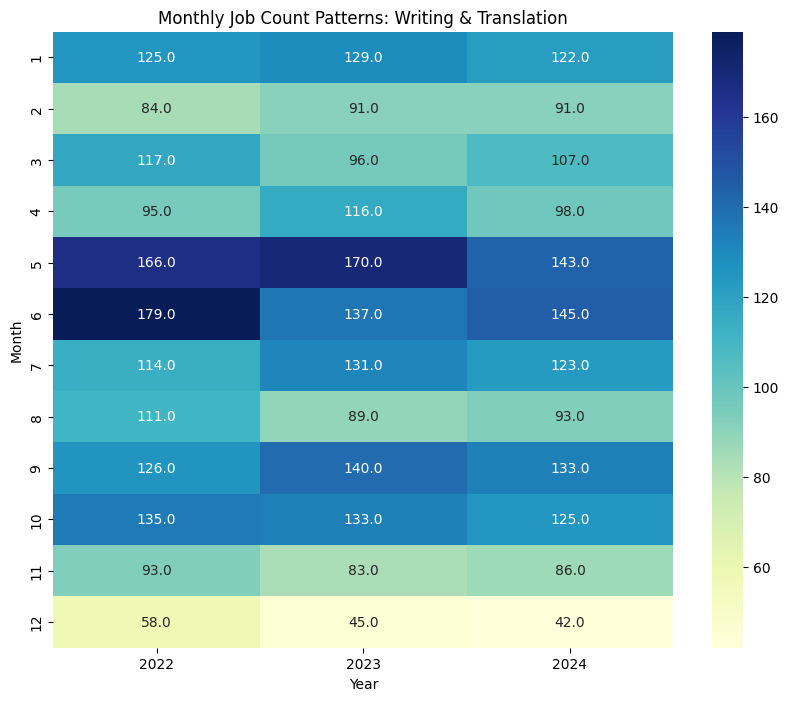

In [ ]:
# Create a heatmap to visualize monthly patterns across years
print("\nCreating heatmap to visualize monthly patterns...")
# Reshape data to show month-by-year patterns
for category in top_categories:
    ts = monthly_counts[category]
    ts_df = pd.DataFrame(ts)
    ts_df['year'] = ts_df.index.year
    ts_df['month'] = ts_df.index.month
    pivot_table = ts_df.pivot_table(index='month', columns='year', values=category, aggfunc='mean')

    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title(f'Monthly Job Count Patterns: {category}')
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.savefig(f'time_series_analysis/{category.replace("/", "_")}_heatmap.png')
    plt.show()
    plt.close()




Calculating year-over-year growth rates...
Yearly totals:
                Accounting & Consulting  Admin Support  Customer Service  \
published_date                                                             
2022-12-31                          367            972               105   
2023-12-31                          389            927                78   
2024-12-31                          395           1031                97   

                Data Science & Analytics  Design & Creative  \
published_date                                                
2022-12-31                           742               2200   
2023-12-31                           735               2208   
2024-12-31                           822               2094   

                Engineering & Architecture  HR & Recruiting  Legal  \
published_date                                                       
2022-12-31                             139              119    113   
2023-12-31                        

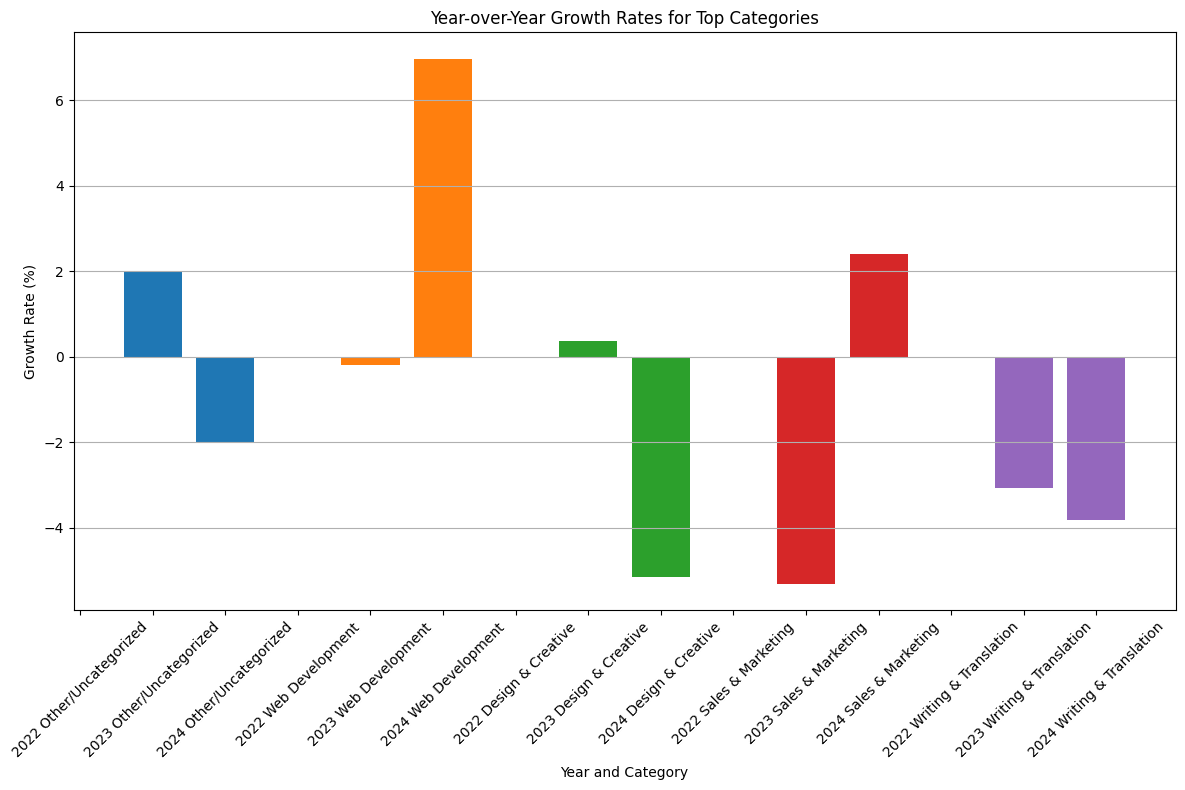

In [ ]:
# Calculate year-over-year growth rates
print("\nCalculating year-over-year growth rates...")
# Group by year and calculate total jobs per year
yearly_totals = monthly_counts.resample('Y').sum()
print("Yearly totals:")
print(yearly_totals)

# Calculate growth rates
growth_rates = pd.DataFrame()
for category in monthly_counts.columns:
    yearly_category = yearly_totals[category]
    growth = yearly_category.pct_change() * 100  # Convert to percentage
    growth_rates[category] = growth

print("\nYear-over-year growth rates (%):")
print(growth_rates)

# Plot growth rates for top categories
plt.figure(figsize=(12, 8))
for category in top_categories:
    plt.bar(growth_rates.index.year.astype(str) + ' ' + category,
            growth_rates[category],
            label=category)
plt.title('Year-over-Year Growth Rates for Top Categories')
plt.xlabel('Year and Category')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('time_series_analysis/growth_rates.png')
plt.show()
plt.close()


In [ ]:
# !pip uninstall -y numpy pandas statsmodels scikit-learn
# !pip install numpy==1.24.3
# !pip install pandas statsmodels scikit-learn
# !pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

# !pip install pmdarima
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

# Step 4: Apply forecasting models for 2025 predictions
print("Step 4: Applying forecasting models for 2025 predictions...")

# Load the preprocessed data
monthly_counts = pd.read_csv('monthly_job_counts_36m.csv', index_col='published_date', parse_dates=True)
print(f"Loaded time series data with shape: {monthly_counts.shape}")

# Create output directory for forecasts
import os
if not os.path.exists('forecasts'):
    os.makedirs('forecasts')

# Define forecast horizon (12 months for 2025)
forecast_horizon = 12

# Dictionary to store forecasts for all categories
all_forecasts = {}
all_confidence_intervals = {}
model_metrics = {}

# 4.1 Apply auto_arima to find the best model for each category
print("\n4.1 Finding optimal ARIMA/SARIMA parameters for each category...")

# Get top categories for detailed analysis
top_categories = monthly_counts.sum().sort_values(ascending=False).head(5).index.tolist()
all_categories = monthly_counts.columns.tolist()

# Function to calculate forecast accuracy metrics
def calculate_metrics(actual, predicted):
    mse = np.mean((actual - predicted) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(actual - predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

# Process each category
for category in all_categories:
    print(f"\nProcessing category: {category}")

    # Extract the time series for this category
    ts = monthly_counts[category]

    try:
        # Split data into train and test sets (last 6 months for testing)
        train_size = len(ts) - 6
        train, test = ts[:train_size], ts[train_size:]
        print(f"Training data: {len(train)} months, Test data: {len(test)} months")

        # Use auto_arima to find the best model
        print(f"Finding best SARIMA model for {category}...")
        auto_model = auto_arima(
            train,
            seasonal=True,
            m=12,  # Monthly data, so seasonality is 12
            start_p=0, start_q=0,
            max_p=3, max_q=3,
            start_P=0, start_Q=0,
            max_P=2, max_Q=2,
            d=None, D=None,  # Let auto_arima determine differencing
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True
        )

        # Get the best model parameters
        order = auto_model.order
        seasonal_order = auto_model.seasonal_order
        print(f"Best model for {category}: SARIMA{order}{seasonal_order}")

        # Fit the model on the full dataset
        print(f"Fitting SARIMA model for {category}...")
        model = SARIMAX(
            ts,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        model_fit = model.fit(disp=False)

        # Generate forecasts for 2025
        print(f"Generating forecasts for {category}...")
        forecast = model_fit.get_forecast(steps=forecast_horizon)
        forecast_mean = forecast.predicted_mean
        forecast_ci = forecast.conf_int()

        # Create forecast index (dates for 2025)
        last_date = ts.index[-1]
        forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_horizon, freq='ME')

        # Store forecasts with proper dates
        forecast_mean.index = forecast_index
        forecast_ci.index = forecast_index

        # Store results
        all_forecasts[category] = forecast_mean
        all_confidence_intervals[category] = forecast_ci

        # Calculate in-sample metrics
        in_sample_pred = model_fit.get_prediction(start=train_size, end=len(ts)-1)
        in_sample_mean = in_sample_pred.predicted_mean
        metrics = calculate_metrics(test, in_sample_mean)
        model_metrics[category] = {
            'order': order,
            'seasonal_order': seasonal_order,
            'metrics': metrics
        }
        print(f"Model metrics for {category}: RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")

        # Plot actual vs predicted for validation period
        if category in top_categories:
            plt.figure(figsize=(12, 6))
            plt.plot(test.index, test, label='Actual', marker='o')
            plt.plot(in_sample_mean.index, in_sample_mean, label='Predicted', marker='x')
            plt.title(f'Model Validation: {category}')
            plt.xlabel('Date')
            plt.ylabel('Number of Job Postings')
            plt.legend()
            plt.grid(True)
            plt.savefig(f'forecasts/{category.replace("/", "_")}_validation.png')
            plt.show()
            plt.close()

            # Plot historical data and forecast
            plt.figure(figsize=(15, 6))
            plt.plot(ts.index, ts, label='Historical Data', marker='o')
            plt.plot(forecast_mean.index, forecast_mean, label='Forecast', marker='x')
            plt.fill_between(
                forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='k', alpha=0.1, label='95% Confidence Interval'
            )
            plt.title(f'Job Trend Forecast for 2025: {category}')
            plt.xlabel('Date')
            plt.ylabel('Number of Job Postings')
            plt.legend()
            plt.grid(True)
            plt.savefig(f'forecasts/{category.replace("/", "_")}_forecast.png')
            plt.show()
            plt.close()

    except Exception as e:
        print(f"Error forecasting {category}: {e}")
        # Fallback to simple exponential smoothing or moving average
        print(f"Using fallback method for {category}...")

        # Simple moving average forecast
        window = 3  # Use last 3 months average
        ma_forecast = ts[-window:].mean()
        forecast_values = np.full(forecast_horizon, ma_forecast)
        forecast_index = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=forecast_horizon, freq='ME')

        all_forecasts[category] = pd.Series(forecast_values, index=forecast_index)

        # Simple confidence interval (±10%)
        lower_bound = forecast_values * 0.9
        upper_bound = forecast_values * 1.1
        ci_df = pd.DataFrame({
            'lower': lower_bound,
            'upper': upper_bound
        }, index=forecast_index)
        all_confidence_intervals[category] = ci_df

        model_metrics[category] = {
            'order': 'Fallback',
            'seasonal_order': 'N/A',
            'metrics': {'RMSE': np.nan, 'MAPE': np.nan}
        }

# 4.2 Combine all forecasts into a DataFrame
print("\n4.2 Combining all forecasts...")
forecast_df = pd.DataFrame(all_forecasts)
forecast_df.to_csv('forecasts/all_forecasts_2025.csv')


# 4.3 Save model metrics
print("\n4.3 Saving model metrics...")
metrics_df = pd.DataFrame({
    category: {
        'order': str(info['order']),
        'seasonal_order': str(info['seasonal_order']),
        'RMSE': info['metrics']['RMSE'],
        'MAPE': info['metrics']['MAPE']
    }
    for category, info in model_metrics.items()
}).T
metrics_df.to_csv('forecasts/model_metrics.csv')


# 4.4 Create a summary of forecasts
print("\n4.4 Creating forecast summary...")
# Calculate average monthly job count for 2024 (last 12 months of data)
last_year_avg = monthly_counts.iloc[-12:].mean()
# Calculate average monthly job count for 2025 (forecast)
forecast_avg = forecast_df.mean()
# Calculate growth rate
growth_rate = ((forecast_avg - last_year_avg) / last_year_avg) * 100

summary_df = pd.DataFrame({
    '2024_Monthly_Avg': last_year_avg,
    '2025_Monthly_Avg_Forecast': forecast_avg,
    'Growth_Rate_Percent': growth_rate
})
summary_df = summary_df.sort_values('Growth_Rate_Percent', ascending=False)
summary_df.to_csv('forecasts/forecast_summary.csv')
print(summary_df)

print("\nForecasting complete.")


ModuleNotFoundError: No module named 'pmdarima'

Step 5: Visualizing forecasts and patterns...
Loaded historical data with shape: (36, 14)
Loaded forecast data with shape: (12, 14)

5.1 Creating comprehensive forecast plots for each category...
Creating detailed visualizations for 11 key categories...
Visualizing Accounting & Consulting...
Visualizing HR & Recruiting...
Visualizing Engineering & Architecture...
Visualizing Other/Uncategorized...
Visualizing Writing & Translation...
Visualizing Web Development...
Visualizing Admin Support...
Visualizing Customer Service...
Visualizing Sales & Marketing...
Visualizing Design & Creative...
Visualizing Legal...

5.2 Creating growth rate comparison chart...

5.3 Creating forecast heatmap for 2025...


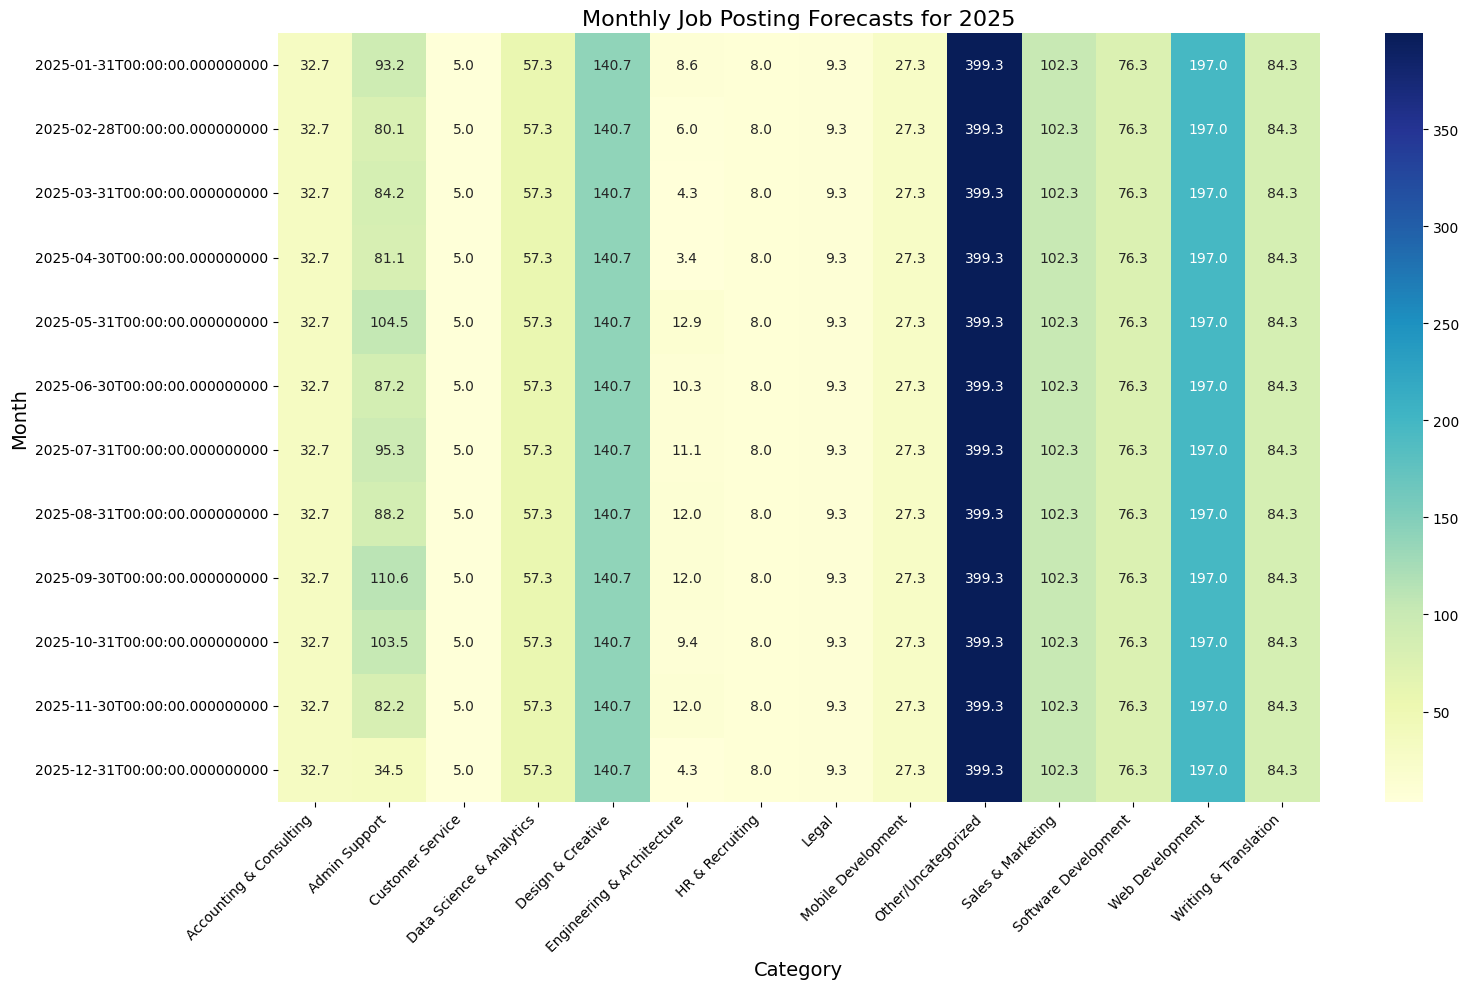


5.4 Creating 2024 vs 2025 comparison chart...


<Figure size 1400x1000 with 0 Axes>

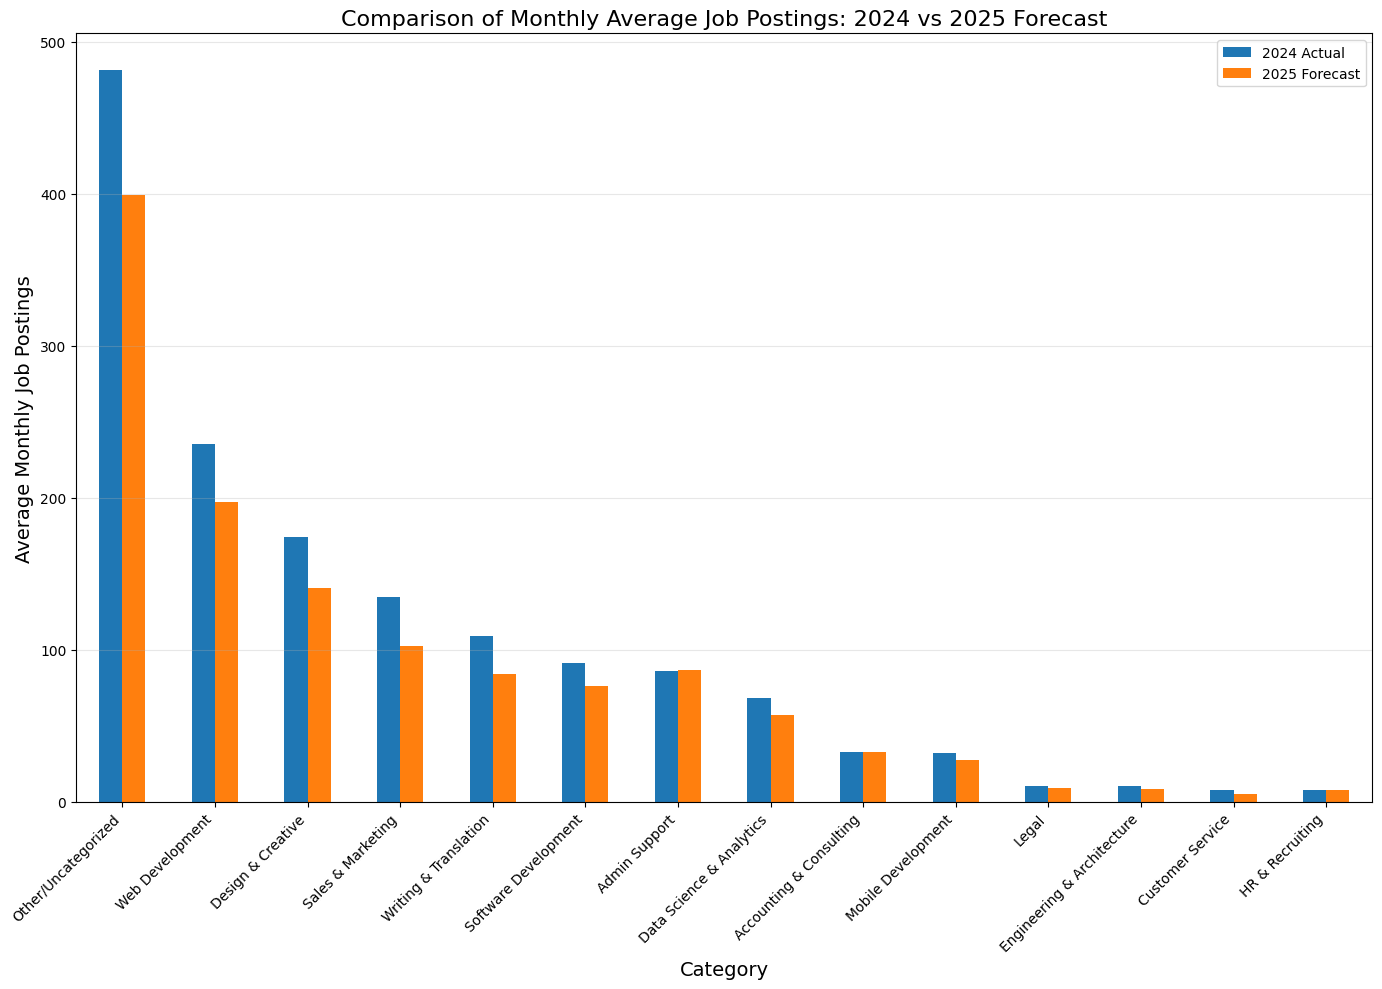


5.5 Creating overall job market trend visualization...


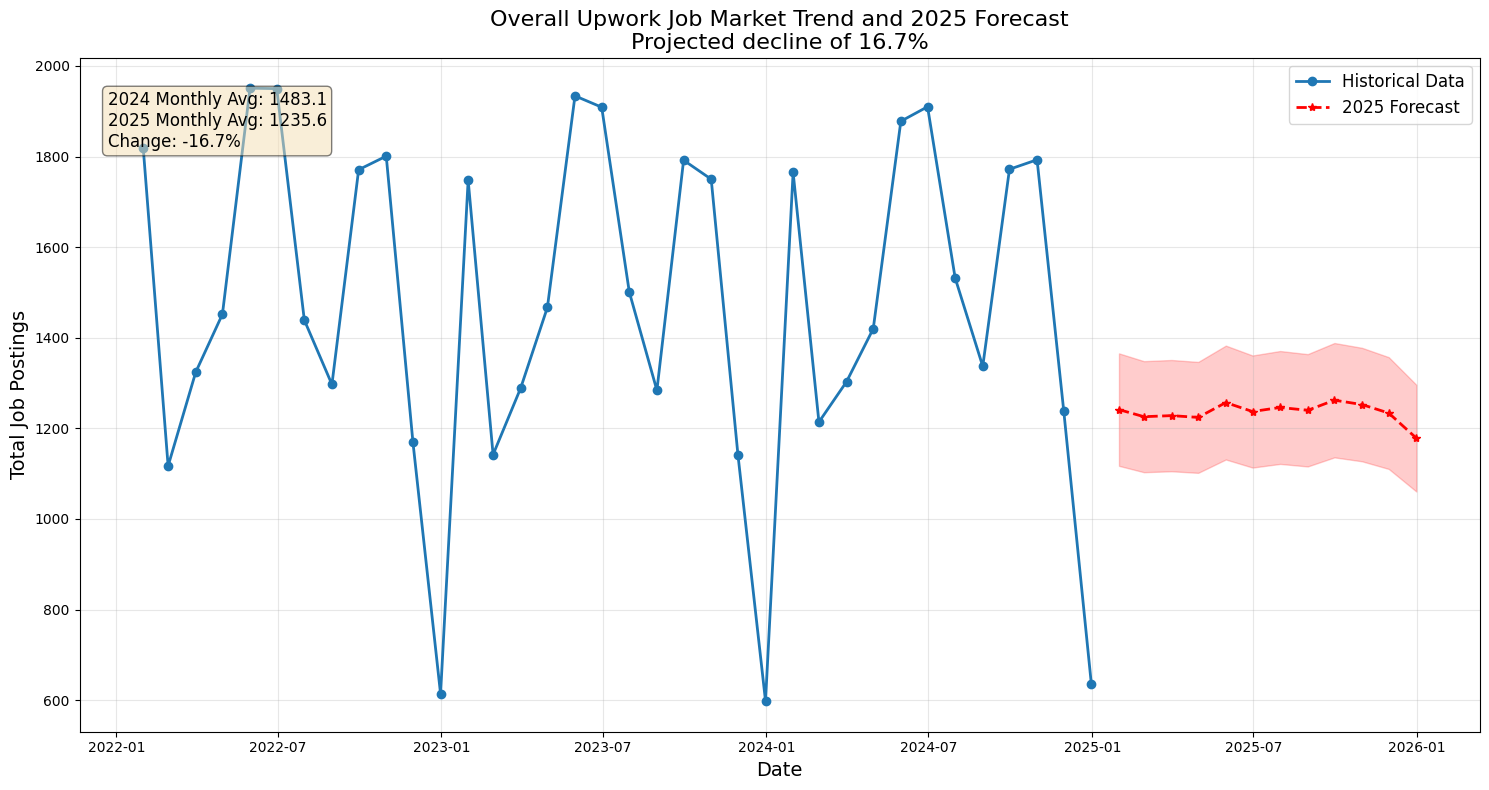

In [ ]:

import os
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')

# Step 5: Visualize forecasts and patterns
print("Step 5: Visualizing forecasts and patterns...")

# Create output directory for visualizations
if not os.path.exists('final_visualizations'):
    os.makedirs('final_visualizations')

# Load the data
monthly_counts = pd.read_csv('monthly_job_counts_36m.csv', index_col='published_date', parse_dates=True)
forecasts = pd.read_csv('forecasts/all_forecasts_2025.csv', index_col=0, parse_dates=True)
forecast_summary = pd.read_csv('forecasts/forecast_summary.csv', index_col=0)

print(f"Loaded historical data with shape: {monthly_counts.shape}")
print(f"Loaded forecast data with shape: {forecasts.shape}")

# 5.1 Create comprehensive forecast plots for each category
print("\nCreating comprehensive forecast plots for each category...")

# Get top growing and declining categories
top_growing = forecast_summary.sort_values('Growth_Rate_Percent', ascending=False).head(5).index.tolist()
top_declining = forecast_summary.sort_values('Growth_Rate_Percent', ascending=True).head(5).index.tolist()

# Combine with top categories by volume
top_by_volume = monthly_counts.sum().sort_values(ascending=False).head(5).index.tolist()
categories_to_plot = list(set(top_growing + top_declining + top_by_volume))

print(f"Creating detailed visualizations for {len(categories_to_plot)} key categories...")

for category in categories_to_plot:
    print(f"Visualizing {category}...")

    # Extract historical and forecast data
    historical = monthly_counts[category]
    forecast = forecasts[category]

    # Create a comprehensive visualization
    fig, ax = plt.subplots(figsize=(15, 8))

    # Plot historical data with different colors by year
    for year in range(2022, 2025):
        year_data = historical[historical.index.year == year]
        ax.plot(year_data.index, year_data.values,
                marker='o', linewidth=2,
                label=f'{year} Actual')

    # Plot forecast with distinctive style
    ax.plot(forecast.index, forecast.values,
            marker='*', linestyle='--', linewidth=2, color='red',
            label='2025 Forecast')

    # Add shaded area for forecast uncertainty (±10%)
    ax.fill_between(forecast.index,
                   forecast.values * 0.9,
                   forecast.values * 1.1,
                   color='red', alpha=0.2)

    # Calculate year-over-year growth rate
    growth_rate = forecast_summary.loc[category, 'Growth_Rate_Percent']
    growth_direction = "growth" if growth_rate > 0 else "decline"

    # Add title and labels with growth information
    ax.set_title(f'{category}: Historical Trend and 2025 Forecast\n'
                f'Projected {growth_direction} of {abs(growth_rate):.1f}%',
                fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Number of Job Postings', fontsize=12)

    # Format x-axis to show months and years
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    # Add grid for better readability
    ax.grid(True, alpha=0.3)

    # Add legend
    ax.legend(fontsize=12)

    # Add annotations for key insights
    avg_2024 = forecast_summary.loc[category, '2024_Monthly_Avg']
    avg_2025 = forecast_summary.loc[category, '2025_Monthly_Avg_Forecast']

    # Add text box with key metrics
    textstr = f'2024 Monthly Avg: {avg_2024:.1f}\n2025 Monthly Avg: {avg_2025:.1f}\nChange: {growth_rate:.1f}%'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.savefig(f'final_visualizations/{category.replace("/", "_")}_complete_forecast.png')
    plt.close()

# Create a growth rate comparison chart
print("\n Creating growth rate comparison chart...")
plt.figure(figsize=(14, 10))
bars = plt.barh(forecast_summary.index, forecast_summary['Growth_Rate_Percent'])

# Color bars based on growth (positive/negative)
for i, bar in enumerate(bars):
    if forecast_summary['Growth_Rate_Percent'].iloc[i] > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

plt.axvline(x=0, color='black', linestyle='-', alpha=0.7)
plt.title('Projected Growth Rate by Category for 2025', fontsize=16)
plt.xlabel('Growth Rate (%)', fontsize=14)
plt.ylabel('Category', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add value labels to bars
for i, v in enumerate(forecast_summary['Growth_Rate_Percent']):
    plt.text(v + (1 if v >= 0 else -1),
             i,
             f'{v:.1f}%',
             va='center',
             fontsize=10)

plt.tight_layout()
plt.savefig('final_visualizations/growth_rate_comparison.png')
plt.close()

# Create a heatmap of monthly forecast values for 2025
print("\n Creating forecast heatmap for 2025...")
plt.figure(figsize=(16, 10))
sns.heatmap(forecasts, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Monthly Job Posting Forecasts for 2025', fontsize=16)
plt.ylabel('Month', fontsize=14)
plt.xlabel('Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_visualizations/forecast_heatmap_2025.png')
plt.show()
plt.close()

# Create a comparison of 2024 vs 2025 monthly averages
print("\n Creating 2024 vs 2025 comparison chart")
comparison_data = forecast_summary[['2024_Monthly_Avg', '2025_Monthly_Avg_Forecast']].sort_values('2024_Monthly_Avg', ascending=False)

plt.figure(figsize=(14, 10))
comparison_data.plot(kind='bar', figsize=(14, 10))
plt.title('Comparison of Monthly Average Job Postings: 2024 vs 2025 Forecast', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Average Monthly Job Postings', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(['2024 Actual', '2025 Forecast'])
plt.tight_layout()
plt.savefig('final_visualizations/monthly_avg_comparison.png')
plt.show()
plt.close()

# Create a visualization of the overall job market trend
print("\n Creating overall job market trend visualization...")
# Calculate total jobs per month
monthly_totals = monthly_counts.sum(axis=1)
forecast_totals = forecasts.sum(axis=1)

plt.figure(figsize=(15, 8))
plt.plot(monthly_totals.index, monthly_totals.values, marker='o', linewidth=2, label='Historical Data')
plt.plot(forecast_totals.index, forecast_totals.values, marker='*', linestyle='--', linewidth=2, color='red', label='2025 Forecast')

# Add shaded area for forecast uncertainty
plt.fill_between(forecast_totals.index,
                forecast_totals.values * 0.9,
                forecast_totals.values * 1.1,
                color='red', alpha=0.2)

# Calculate overall growth rate
total_2024_avg = monthly_totals[-12:].mean()
total_2025_avg = forecast_totals.mean()
overall_growth = ((total_2025_avg - total_2024_avg) / total_2024_avg) * 100

plt.title(f'Overall Upwork Job Market Trend and 2025 Forecast\n'
          f'Projected {"growth" if overall_growth > 0 else "decline"} of {abs(overall_growth):.1f}%',
          fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Job Postings', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add text box with key metrics
textstr = f'2024 Monthly Avg: {total_2024_avg:.1f}\n2025 Monthly Avg: {total_2025_avg:.1f}\nChange: {overall_growth:.1f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.02, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('final_visualizations/overall_market_trend.png')
plt.show()
plt.close()